<a href="https://colab.research.google.com/github/VukasinA/ML_projekti/blob/main/d2_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer

In [ ]:
def preprocess_data(df):
    df = df.copy()

    # Popunjavanje nedostajucih vrednosti
    df['Age'] = df['Age'].fillna(df['Age'].median())
    df['Fare'] = df['Fare'].fillna(df['Fare'].median())
    df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

    # Pretvaranje kategorijskih promenljivih
    df['Sex'] = LabelEncoder().fit_transform(df['Sex'])
    df['Embarked'] = LabelEncoder().fit_transform(df['Embarked'])

    # Izvodjenje featuresa iz postojecih
    df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
    df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

    return df[['Pclass', 'Sex', 'Age', 'Fare', 'Embarked', 'FamilySize', 'IsAlone']]

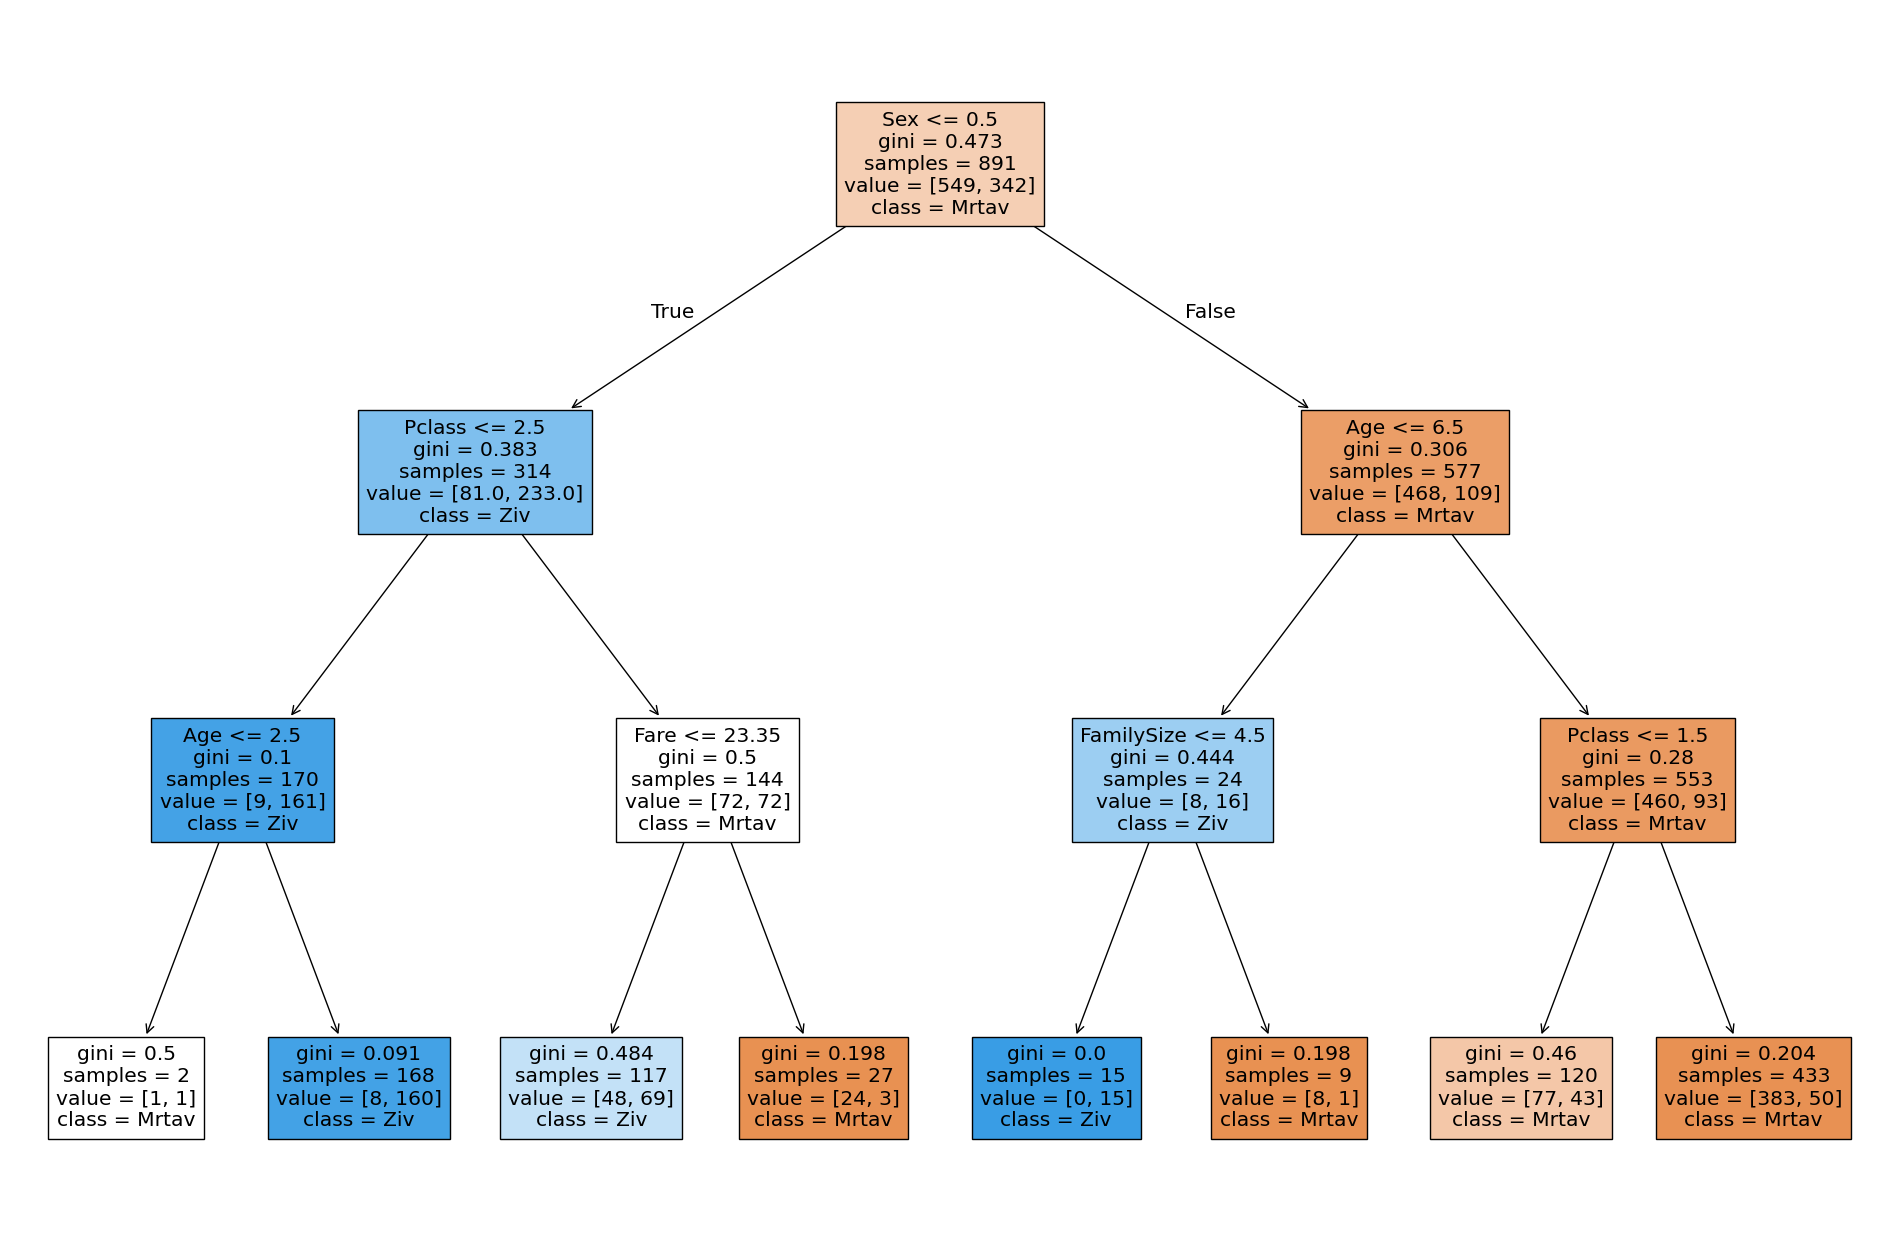

Accuracy: 82.716 %


In [ ]:
# Učitavanje podataka
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

# Spajanje podataka za preprocesiranje
combined = pd.concat([train_df, test_df], sort=False)

# Preprocesiranje
X_combined = preprocess_data(combined)
X_train = X_combined.iloc[:len(train_df)]
y_train = train_df['Survived']
X_test = X_combined.iloc[len(train_df):]

# Kreiranje i treniranje stabla
tree = DecisionTreeClassifier(max_depth=3, random_state=42)
tree.fit(X_train, y_train)

# Vizuelizacija stabla
plt.figure(figsize=(24, 16))
plot_tree(tree,
          feature_names=X_train.columns,
          class_names=['Mrtav', 'Ziv'],
          filled=True)

plt.show()

# Testiranje na trening podacima
train_predictions = tree.predict(X_train)
accuracy = (train_predictions == y_train).mean()
print(f"Accuracy: {100 * accuracy:.3f} %")